# ELEC 576 / COMP 576 — Fall 2026
## Homework 1 (Assignment 0)

**Name:** zhangkeli  
**NetID:** zl210  
**Date:** September 16, 2026

This report records the requested environment checks, NumPy linear
algebra commands, and Matplotlib figures. All Python cells were run in
Jupyter/IPython using the `comp576` Conda environment.

## Task 1 — Conda information

I installed Miniconda and created a separate `comp576` environment.
I activated it and ran `conda info` in the terminal. The result was:

```text
     active environment : comp576
    active env location : /home/zhangke/miniconda3/envs/comp576
            shell level : 1
       user config file : /home/zhangke/.condarc
 populated config files : /home/zhangke/miniconda3/.condarc
                          /home/zhangke/miniconda3/condarc.d/anaconda-auth.yml
          conda version : 25.11.1
    conda-build version : not installed
         python version : 3.13.11.final.0
                 solver : libmamba (default)
       virtual packages : __archspec=1=zen5
                          __conda=25.11.1=0
                          __cuda=12.8=0
                          __glibc=2.39=0
                          __linux=6.8.0=0
                          __unix=0=0
       base environment : /home/zhangke/miniconda3  (writable)
      conda av data dir : /home/zhangke/miniconda3/etc/conda
  conda av metadata url : None
           channel URLs : https://repo.anaconda.com/pkgs/main/linux-64
                          https://repo.anaconda.com/pkgs/main/noarch
                          https://repo.anaconda.com/pkgs/r/linux-64
                          https://repo.anaconda.com/pkgs/r/noarch
          package cache : /home/zhangke/miniconda3/pkgs
                          /home/zhangke/.conda/pkgs
       envs directories : /home/zhangke/miniconda3/envs
                          /home/zhangke/.conda/envs
               platform : linux-64
             user-agent : conda/25.11.1 requests/2.32.5 CPython/3.13.11
                          Linux/6.8.0-138-generic ubuntu/24.04.4 glibc/2.39
                          solver/libmamba conda-libmamba-solver/25.11.0
                          libmambapy/2.3.2 aau/0.7.5 c/. s/. e/.
                UID:GID : 1010:1010
             netrc file : None
           offline mode : False
```

The `python version` line above is the Python used internally by the
base Conda installation. The activated course environment and this
notebook use Python 3.12.14, as verified below.

In [1]:
import sys
import numpy as np
import scipy
import scipy.linalg
import matplotlib

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.12.14
NumPy: 2.4.3
SciPy: 1.17.1
Matplotlib: 3.10.8


## Task 2 — NumPy “Linear algebra equivalents”

The following cells run every Python command in the current NumPy
documentation's **Linear algebra equivalents** table. I use a symmetric
positive-definite 5 × 5 matrix so the same data works for solving,
Cholesky factorization, eigenvalue calculations, and slicing.

In [2]:
import numpy as np
from scipy import linalg, signal
from scipy.sparse.linalg import cg, eigs

np.set_printoptions(precision=4, suppress=True)

a = np.array([
    [6., 1., 0., 0., 1.],
    [1., 7., 1., 0., 0.],
    [0., 1., 8., 1., 0.],
    [0., 0., 1., 9., 1.],
    [1., 0., 0., 1., 10.],
])
b = np.array([1., 2., 3., 4., 5.])

print("a =\n", a)
print("b =", b)

a =
 [[ 6.  1.  0.  0.  1.]
 [ 1.  7.  1.  0.  0.]
 [ 0.  1.  8.  1.  0.]
 [ 0.  0.  1.  9.  1.]
 [ 1.  0.  0.  1. 10.]]
b = [1. 2. 3. 4. 5.]


### Array dimensions and construction

In [3]:
# ndims(a), numel(a), size(a), and size(a,n)
print("np.ndim(a):", np.ndim(a))
print("a.ndim:", a.ndim)
print("np.size(a):", np.size(a))
print("a.size:", a.size)
print("np.shape(a):", np.shape(a))
print("a.shape:", a.shape)
print("a.shape[1] (MATLAB size(a,2)):", a.shape[1])

# [1 2 3; 4 5 6]
literal = np.array([[1., 2., 3.], [4., 5., 6.]])
print("\n2 x 3 array literal:\n", literal)

# [A B; C D]
A = np.array([[1., 2.], [3., 4.]])
B = np.array([[5.], [6.]])
C = np.array([[7., 8.]])
D = np.array([[9.]])
blocked = np.block([[A, B], [C, D]])
print("\nnp.block([[A, B], [C, D]]):\n", blocked)

np.ndim(a): 2
a.ndim: 2
np.size(a): 25
a.size: 25
np.shape(a): (5, 5)
a.shape: (5, 5)
a.shape[1] (MATLAB size(a,2)): 5

2 x 3 array literal:
 [[1. 2. 3.]
 [4. 5. 6.]]

np.block([[A, B], [C, D]]):
 [[1. 2. 5.]
 [3. 4. 6.]
 [7. 8. 9.]]


### Indexing and slicing

In [4]:
# a(end), a(2,5), a(2,:), and a(1:5,:)
print("a[-1] (last row):", a[-1])
print("a[1, 4] (row 2, column 5):", a[1, 4])
print("a[1] (entire second row):", a[1])
print("a[1, :] (entire second row):", a[1, :])
print("a[0:5] (first five rows):\n", a[0:5])
print("a[:5, :] (same slice):\n", a[:5, :])

a[-1] (last row): [ 1.  0.  0.  1. 10.]
a[1, 4] (row 2, column 5): 0.0
a[1] (entire second row): [1. 7. 1. 0. 0.]
a[1, :] (entire second row): [1. 7. 1. 0. 0.]
a[0:5] (first five rows):
 [[ 6.  1.  0.  0.  1.]
 [ 1.  7.  1.  0.  0.]
 [ 0.  1.  8.  1.  0.]
 [ 0.  0.  1.  9.  1.]
 [ 1.  0.  0.  1. 10.]]
a[:5, :] (same slice):
 [[ 6.  1.  0.  0.  1.]
 [ 1.  7.  1.  0.  0.]
 [ 0.  1.  8.  1.  0.]
 [ 0.  0.  1.  9.  1.]
 [ 1.  0.  0.  1. 10.]]


### Linear systems

In [5]:
# MATLAB a\\b: solve a x = b
x_left = linalg.solve(a, b)
print("linalg.solve(a, b):", x_left)
print("check a @ x:", a @ x_left)

# MATLAB b/a: solve x a = b by transposing
x_right = linalg.solve(a.T, b.T).T
print("\nright-division equivalent:", x_right)
print("check x @ a:", x_right @ a)

linalg.solve(a, b): [0.0509 0.2355 0.3006 0.3601 0.4589]
check a @ x: [1. 2. 3. 4. 5.]

right-division equivalent: [0.0509 0.2355 0.3006 0.3601 0.4589]
check x @ a: [1. 2. 3. 4. 5.]


### Matrix decompositions and eigenvalue problems

In [6]:
# Singular value decomposition: [U,S,V] = svd(a)
U, S, Vh = linalg.svd(a)
V = Vh.T
print("Singular values S:", S)
print("SVD reconstruction error:", np.linalg.norm(a - U @ np.diag(S) @ V.T))

# Cholesky factorization
L_chol = linalg.cholesky(a, lower=True)
print("\nCholesky factor L:\n", L_chol)
print("Cholesky reconstruction error:", np.linalg.norm(a - L_chol @ L_chol.T))

# Standard eigenvalue problem
D_eig, V_eig = linalg.eig(a)
print("\nEigenvalues:", D_eig)
print("Eigenpair residual:", np.linalg.norm(a @ V_eig - V_eig @ np.diag(D_eig)))

# Generalized eigenvalue problem a v = lambda B v
B_general = np.diag([1., 2., 3., 4., 5.])
D_gen, V_gen = linalg.eig(a, B_general)
print("\nGeneralized eigenvalues:", D_gen)
print("Generalized residual:",
      np.linalg.norm(a @ V_gen - B_general @ V_gen @ np.diag(D_gen)))

# Three eigenvalues/eigenvectors with scipy.sparse.linalg.eigs
D_sparse, V_sparse = eigs(a, k=3)
print("\neigs(a, k=3) eigenvalues:", D_sparse)
print("eigs residual:",
      np.linalg.norm(a @ V_sparse - V_sparse @ np.diag(D_sparse)))

Singular values S: [10.9015  9.2004  8.145   6.6182  5.1347]
SVD reconstruction error: 1.1208808842061426e-14

Cholesky factor L:
 [[ 2.4495  0.      0.      0.      0.    ]
 [ 0.4082  2.6141  0.      0.      0.    ]
 [ 0.      0.3825  2.8024  0.      0.    ]
 [ 0.      0.      0.3568  2.9787  0.    ]
 [ 0.4082 -0.0638  0.0087  0.3347  3.1172]]
Cholesky reconstruction error: 1.538487546143561e-15

Eigenvalues: [ 5.1347+0.j 10.9015+0.j  6.6182+0.j  8.145 +0.j  9.2004+0.j]
Eigenpair residual: 6.507754024187996e-15

Generalized eigenvalues: [6.2336+0.j 3.5174+0.j 1.8075+0.j 2.1784+0.j 2.6798+0.j]
Generalized residual: 1.414313400848712e-14

eigs(a, k=3) eigenvalues: [10.9015+0.j  9.2004+0.j  8.145 +0.j]
eigs residual: 1.0088989477484783e-14


In [7]:
# QR decomposition
Q, R = linalg.qr(a)
print("QR reconstruction error:", np.linalg.norm(a - Q @ R))
print("Q orthogonality error:", np.linalg.norm(Q.T @ Q - np.eye(5)))

# LU decomposition with partial pivoting
P, L, U_lu = linalg.lu(a)
print("\nP =\n", P)
print("L =\n", L)
print("U =\n", U_lu)
print("LU reconstruction error:", np.linalg.norm(a - P @ L @ U_lu))

# Conjugate-gradient solver
x_cg, info = cg(a, b)
print("\ncg solution:", x_cg)
print("cg info (0 means success):", info)
print("cg residual:", np.linalg.norm(a @ x_cg - b))

QR reconstruction error: 2.936513067998123e-15
Q orthogonality error: 2.616511975367185e-16

P =
 [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
L =
 [[ 1.      0.      0.      0.      0.    ]
 [ 0.1667  1.      0.      0.      0.    ]
 [ 0.      0.1463  1.      0.      0.    ]
 [ 0.      0.      0.1273  1.      0.    ]
 [ 0.1667 -0.0244  0.0031  0.1124  1.    ]]
U =
 [[ 6.      1.      0.      0.      1.    ]
 [ 0.      6.8333  1.      0.     -0.1667]
 [ 0.      0.      7.8537  1.      0.0244]
 [ 0.      0.      0.      8.8727  0.9969]
 [ 0.      0.      0.      0.      9.7172]]
LU reconstruction error: 1.1133467212449447e-16

cg solution: [0.0509 0.2355 0.3006 0.3601 0.4589]
cg info (0 means success): 0
cg residual: 9.155133597044475e-16


### Fourier transforms, sorting, regression, resampling, and shapes

In [8]:
# Fourier transform and inverse Fourier transform
fft_result = np.fft.fft(b)
ifft_result = np.fft.ifft(fft_result)
print("np.fft.fft(b):", fft_result)
print("np.fft.ifft(fft_result):", ifft_result)

# Sort columns and rows
unsorted = np.array([[3., 1., 9.], [1., 4., 5.], [2., 0., 7.]])
print("\nOriginal array:\n", unsorted)
print("np.sort(unsorted, axis=0):\n", np.sort(unsorted, axis=0))
print("np.sort(unsorted, axis=1):\n", np.sort(unsorted, axis=1))

# Sort rows by the first column
I = np.argsort(unsorted[:, 0])
sorted_rows = unsorted[I, :]
print("Row order I:", I)
print("Rows sorted by first column:\n", sorted_rows)

np.fft.fft(b): [15. +0.j     -2.5+3.441j  -2.5+0.8123j -2.5-0.8123j -2.5-3.441j ]
np.fft.ifft(fft_result): [1.+0.j 2.+0.j 3.+0.j 4.+0.j 5.+0.j]

Original array:
 [[3. 1. 9.]
 [1. 4. 5.]
 [2. 0. 7.]]
np.sort(unsorted, axis=0):
 [[1. 0. 5.]
 [2. 1. 7.]
 [3. 4. 9.]]
np.sort(unsorted, axis=1):
 [[1. 3. 9.]
 [1. 4. 5.]
 [0. 2. 7.]]
Row order I: [1 2 0]
Rows sorted by first column:
 [[1. 4. 5.]
 [2. 0. 7.]
 [3. 1. 9.]]


In [9]:
# Linear regression Z x = y using least squares
Z = np.column_stack([np.ones(5), np.arange(5.)])
y = np.array([1.1, 2.9, 5.2, 6.8, 9.1])
x_reg, residuals, rank, singular_values = linalg.lstsq(Z, y)
print("Regression coefficients:", x_reg)
print("Predictions:", Z @ x_reg)
print("Rank:", rank)

# Downsample with Fourier-method resampling
sample = np.sin(np.linspace(0, 4 * np.pi, 20, endpoint=False))
q = 2
downsampled = signal.resample(sample, int(np.ceil(len(sample) / q)))
print("\nOriginal sample length:", len(sample))
print("Resampled length:", len(downsampled))
print("Resampled values:", downsampled)

# Unique values and squeezing singleton dimensions
values = np.array([3, 1, 3, 2, 1, 4])
print("\nnp.unique(values):", np.unique(values))
singleton = np.arange(6).reshape(1, 6, 1)
print("Before squeeze:", singleton.shape)
print("After squeeze:", singleton.squeeze().shape)
print("Squeezed values:", singleton.squeeze())

Regression coefficients: [1.04 1.99]
Predictions: [1.04 3.03 5.02 7.01 9.  ]
Rank: 2

Original sample length: 20
Resampled length: 10
Resampled values: [-0.      0.9511  0.5878 -0.5878 -0.9511 -0.      0.9511  0.5878 -0.5878
 -0.9511]

np.unique(values): [1 2 3 4]
Before squeeze: (1, 6, 1)
After squeeze: (6,)
Squeezed values: [0 1 2 3 4 5]


## Task 3 — Required Matplotlib plot

The following is the assigned script. `savefig` only saves the same
displayed figure for inclusion in the report.

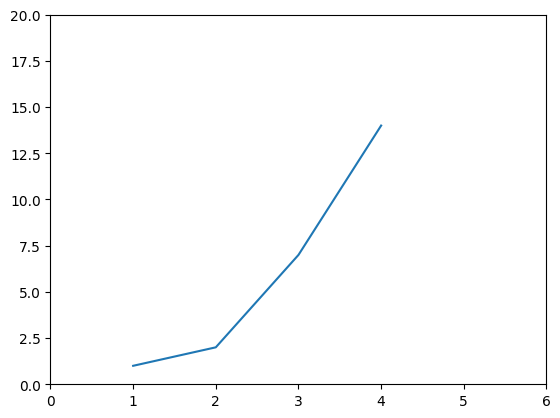

In [10]:
import matplotlib.pyplot as plt

plt.plot([1, 2, 3, 4], [1, 2, 7, 14])
plt.axis([0, 6, 0, 20])
plt.savefig("task3_plot.png", dpi=180, bbox_inches="tight")
plt.show()

## Task 4 — Original Matplotlib figure

I chose a damped cosine signal. Its envelope is
$\pm e^{-0.18t}$, and the oscillation is
$e^{-0.18t}\cos(2\pi t)$.

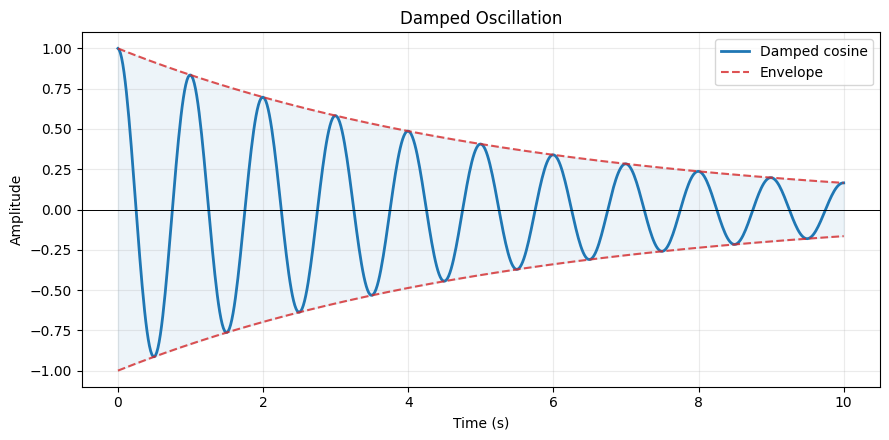

In [11]:
t = np.linspace(0, 10, 600)
envelope = np.exp(-0.18 * t)
y = envelope * np.cos(2 * np.pi * t)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t, y, color="#1f77b4", linewidth=2, label="Damped cosine")
ax.plot(t, envelope, "--", color="#d62728", alpha=0.8, label="Envelope")
ax.plot(t, -envelope, "--", color="#d62728", alpha=0.8)
ax.fill_between(t, -envelope, envelope, color="#1f77b4", alpha=0.08)
ax.axhline(0, color="black", linewidth=0.7)
ax.set(title="Damped Oscillation", xlabel="Time (s)", ylabel="Amplitude")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig("task4_plot.png", dpi=180, bbox_inches="tight")
plt.show()

## Task 5 — Version-control account

**GitHub account:** https://github.com/zhangkel666

## Task 6 — Public IDE project

I created this homework as a project, committed it with Git, and pushed
it to a public GitHub repository.

**Public repository:** https://github.com/zhangkel666/comp576-hw1

## Sources

1. NumPy Developers, [NumPy for MATLAB users](https://numpy.org/doc/stable/user/numpy-for-matlab-users.html).
2. Matplotlib Development Team, [Pyplot tutorial](https://matplotlib.org/stable/tutorials/pyplot.html).
3. Project Jupyter, [Jupyter Documentation](https://docs.jupyter.org/).
4. Anaconda, [Conda documentation](https://docs.conda.io/).